# Week 2 — Data Collection, Cleaning, and Preprocessing for Logistics Analysis
### Regional FMCG Distribution Network — Vijayawada–Amaravati Corridor, Andhra Pradesh

This notebook implements, as **working Python code**, the full data cleaning and preprocessing pipeline
described in the Week 2 report. Since the distributor's real order-management export is not yet available,
a synthetic **"raw" dataset is deliberately generated with realistic data-quality problems** — duplicate rows,
inconsistent identifier casing, missing values, invalid values, and statistical outliers — at rates matching
the Week 2 report's data-quality audit. The notebook then applies, step by step, the same cleaning techniques
proposed in that report, validating the result at each stage.

**Contents**
1. Environment setup
2. Simulating a deliberately messy raw dataset
3. Data quality audit (before cleaning)
4. Structural cleaning & de-duplication
5. Handling missing values
6. Outlier detection & treatment
7. Feature scaling for downstream clustering
8. Final validation & export
9. Before/after summary


## 1. Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (8, 4.5)
rng = np.random.default_rng(7)


## 2. Simulating a Deliberately Messy Raw Dataset

### 2.1 Clean reference tables
The outlet master table represents relatively stable reference data, though even here a small share of
outlets (~3.5%) are missing GPS coordinates — a realistic upstream data-entry gap.

In [2]:
N_OUTLETS = 250
zone_centers = {"North": (16.62, 80.55), "Central": (16.51, 80.62), "South": (16.40, 80.68)}
zones = list(zone_centers.keys())
outlet_zone = rng.choice(zones, size=N_OUTLETS, p=[0.3, 0.4, 0.3])
outlet_lat = np.array([zone_centers[z][0] for z in outlet_zone]) + rng.normal(0, 0.05, N_OUTLETS)
outlet_lon = np.array([zone_centers[z][1] for z in outlet_zone]) + rng.normal(0, 0.05, N_OUTLETS)
cities_by_zone = {"North": "Vijayawada", "Central": "Amaravati", "South": "Guntur"}

outlets = pd.DataFrame({
    "outlet_id": [f"OUT{i:04d}" for i in range(N_OUTLETS)],
    "zone": outlet_zone,
    "city": [cities_by_zone[z] for z in outlet_zone],
    "lat": outlet_lat,
    "lon": outlet_lon,
})

missing_coord_idx = rng.choice(outlets.index, size=int(0.035 * N_OUTLETS), replace=False)
outlets.loc[missing_coord_idx, ["lat", "lon"]] = np.nan
print(f"Outlets with missing coordinates: {outlets[['lat','lon']].isna().any(axis=1).sum()} / {N_OUTLETS}")
outlets.head()


Outlets with missing coordinates: 8 / 250


,outlet_id,zone,city,lat,lon
0,OUT0000,Central,Amaravati,16.399979,80.566212
1,OUT0001,South,Guntur,16.365396,80.732018
2,OUT0002,South,Guntur,16.301560,80.626104
3,OUT0003,North,Vijayawada,16.457428,80.535729
4,OUT0004,Central,Amaravati,16.483494,80.544686


### 2.2 Raw order extract with injected quality issues
A base extract of 20,000 order lines is generated, then six categories of realistic data-quality problems
are deliberately injected at rates consistent with the Week 2 report's audit table:

| Issue | Injected Rate |
|---|---|
| Casing/whitespace inconsistency in identifiers | ~15% (sku_id), ~10% (outlet_id) |
| Duplicate order rows (export retries) | ~1.8% |
| Missing `delivery_date` (cancelled/in-transit) | ~6.4% |
| Missing `promised_date` (data-entry gaps) | ~2.1% |
| Invalid qty/price values (sign errors, export bugs) | ~0.9% |
| Statistical outliers (genuine bulk orders) | ~2.7% |


In [3]:
N_RAW = 20000
sku_pool = [f"SKU-{1000+i}" for i in range(40)]

order_date = pd.Timestamp("2025-01-01") + pd.to_timedelta(rng.integers(0, 240, N_RAW), unit="D")
outlet_choice = rng.choice(outlets["outlet_id"], N_RAW)
sku_choice = rng.choice(sku_pool, N_RAW)
qty = rng.poisson(lam=6, size=N_RAW) + 1
unit_price = rng.uniform(15, 250, N_RAW).round(2)
lead_days = rng.integers(1, 4, N_RAW)
promised_date = order_date + pd.to_timedelta(lead_days, unit="D")
delivered_lead = np.maximum(lead_days + rng.choice([-1, 0, 1, 2], N_RAW, p=[0.1, 0.6, 0.2, 0.1]), 0)
delivery_date = order_date + pd.to_timedelta(delivered_lead, unit="D")

raw = pd.DataFrame({
    "order_id": [f"ORD{100000+i}" for i in range(N_RAW)],
    "order_date": order_date,
    "promised_date": promised_date,
    "delivery_date": delivery_date,
    "outlet_id": outlet_choice,
    "sku_id": sku_choice,
    "qty": qty,
    "unit_price": unit_price,
})
print(f"Base extract: {raw.shape}")


Base extract: (20000, 8)


In [4]:
# --- Inject data-quality problems ---

# 1. Casing / whitespace inconsistency on identifiers
messy_idx = rng.choice(raw.index, size=int(0.15 * N_RAW), replace=False)
raw.loc[messy_idx, "sku_id"] = raw.loc[messy_idx, "sku_id"].str.lower() + "  "
messy_idx2 = rng.choice(raw.index, size=int(0.10 * N_RAW), replace=False)
raw.loc[messy_idx2, "outlet_id"] = " " + raw.loc[messy_idx2, "outlet_id"].str.lower()

# 2. Duplicate order rows from repeated export retries
dup_rows = raw.sample(frac=0.018, random_state=1)
raw = pd.concat([raw, dup_rows], ignore_index=True)

# 3. Missing delivery_date for cancelled / in-transit orders
missing_delivery_idx = rng.choice(raw.index, size=int(0.064 * len(raw)), replace=False)
raw.loc[missing_delivery_idx, "delivery_date"] = pd.NaT

# 4. Missing promised_date due to upstream data-entry gaps
missing_promised_idx = rng.choice(raw.index, size=int(0.021 * len(raw)), replace=False)
raw.loc[missing_promised_idx, "promised_date"] = pd.NaT

# 5. Invalid qty / price values -- sign errors / export bugs
invalid_idx = rng.choice(raw.index, size=int(0.009 * len(raw)), replace=False)
half = len(invalid_idx) // 2
raw.loc[invalid_idx[:half], "qty"] = -raw.loc[invalid_idx[:half], "qty"]
raw.loc[invalid_idx[half:], "unit_price"] = 0

# 6. Statistical outliers -- genuine bulk/institutional orders
outlier_idx = rng.choice(raw.index, size=int(0.027 * len(raw)), replace=False)
raw.loc[outlier_idx, "qty"] = raw.loc[outlier_idx, "qty"] * rng.integers(15, 40, len(outlier_idx))

print(f"Raw (messy) dataset shape after injecting issues: {raw.shape}")
raw.head()


Raw (messy) dataset shape after injecting issues: (20360, 8)


,order_id,order_date,promised_date,delivery_date,outlet_id,sku_id,qty,unit_price
0,ORD100000,2025-04-08,2025-04-09,2025-04-09,OUT0047,SKU-1012,3,116.52
1,ORD100001,2025-02-21,2025-02-24,2025-02-24,OUT0009,SKU-1019,8,190.30
2,ORD100002,2025-08-01,2025-08-02,2025-08-02,OUT0020,SKU-1018,11,116.18
3,ORD100003,2025-05-09,2025-05-10,2025-05-10,OUT0055,sku-1033,6,212.03
4,ORD100004,2025-08-09,2025-08-10,2025-08-10,OUT0025,sku-1034,10,157.44


## 3. Data Quality Audit (Before Cleaning)

Before any cleaning, we quantify each issue category. This becomes the "before" column of the summary
table produced at the end of the notebook.

In [5]:
audit_before = {
    "Total rows": len(raw),
    "Duplicate order_id rows": raw.duplicated(subset=["order_id"]).sum(),
    "Missing delivery_date": raw["delivery_date"].isna().sum(),
    "Missing promised_date": raw["promised_date"].isna().sum(),
    "Non-positive qty": (raw["qty"] <= 0).sum(),
    "Zero/negative unit_price": (raw["unit_price"] <= 0).sum(),
    "sku_id with whitespace/casing issues": raw["sku_id"].ne(raw["sku_id"].str.strip().str.upper()).sum(),
    "Outlets missing coordinates": outlets[["lat", "lon"]].isna().any(axis=1).sum(),
}
audit_before_df = pd.DataFrame.from_dict(audit_before, orient="index", columns=["Count"])
audit_before_df["% of rows"] = (audit_before_df["Count"] / len(raw) * 100).round(2)
audit_before_df


,Count,% of rows
Total rows,20360,100.00
Duplicate order_id rows,360,1.77
Missing delivery_date,1303,6.40
Missing promised_date,427,2.10
Non-positive qty,91,0.45
Zero/negative unit_price,92,0.45
sku_id with whitespace/casing issues,3059,15.02
Outlets missing coordinates,8,0.04


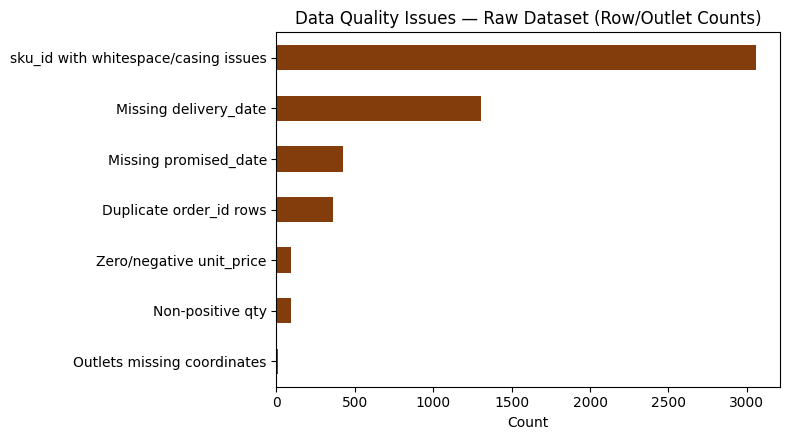

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
issues = audit_before_df.drop("Total rows")["Count"]
issues.sort_values().plot(kind="barh", ax=ax, color="#833C0C")
ax.set_title("Data Quality Issues — Raw Dataset (Row/Outlet Counts)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()


## 4. Structural Cleaning & De-duplication

**Technique:** trim + uppercase all identifier columns, then drop duplicate rows on the natural key
(`order_id`). This is applied first because unresolved identifier mismatches would silently fragment
every later `groupby`/merge operation.

In [7]:
df = raw.copy()

df["sku_id"] = df["sku_id"].astype(str).str.strip().str.upper()
df["outlet_id"] = df["outlet_id"].astype(str).str.strip().str.upper()

before = len(df)
df = df.drop_duplicates(subset=["order_id"])
n_dupes_removed = before - len(df)
print(f"Removed {n_dupes_removed} duplicate rows ({n_dupes_removed/before:.2%} of pre-cleaning rows)")
print(f"Remaining whitespace/casing issues: "
      f"{df['sku_id'].ne(df['sku_id'].str.strip().str.upper()).sum()}")


Removed 360 duplicate rows (1.77% of pre-cleaning rows)


Remaining whitespace/casing issues: 0


## 5. Handling Missing Values

Three different techniques are applied depending on the *meaning* of missingness for each field —
a single blanket imputation strategy would distort the KPIs defined in Week 1.

- **`delivery_date`** → flagged (`delivered_flag`), never imputed, since a fabricated delivery time
  would corrupt the On-Time Delivery Rate and Cycle Time KPIs.
- **`promised_date`** → imputed using the *per-SKU median lead time*, since promised dates follow a
  predictable, low-variance business rule.
- **Outlet coordinates** → resolved via a join against `outlet_master`; any still-missing coordinates
  are resolved with a simulated geocoding fallback keyed on city (standing in for a real geocoding API call).

In [8]:
df["delivered_flag"] = df["delivery_date"].notna()
print(f"delivered_flag distribution:\n{df['delivered_flag'].value_counts()}")


delivered_flag distribution:
delivered_flag
True     18722
False     1278
Name: count, dtype: int64


In [9]:
df["lead_time_days"] = (df["promised_date"] - df["order_date"]).dt.days
median_lead_by_sku = df.groupby("sku_id")["lead_time_days"].transform("median")
missing_promised = df["promised_date"].isna()
df.loc[missing_promised, "promised_date"] = (
    df.loc[missing_promised, "order_date"] + pd.to_timedelta(median_lead_by_sku[missing_promised], unit="D")
)
print(f"Imputed {missing_promised.sum()} missing promised_date values using per-SKU median lead time")
print(f"Remaining missing promised_date: {df['promised_date'].isna().sum()}")


Imputed 419 missing promised_date values using per-SKU median lead time
Remaining missing promised_date: 0


In [10]:
df = df.merge(outlets[["outlet_id", "lat", "lon", "city", "zone"]], on="outlet_id", how="left")

# Simulated geocoding fallback (stands in for a real geocoding API call, e.g. Nominatim/Google Maps)
city_centroid_lookup = {
    "Vijayawada": (16.62, 80.55),
    "Amaravati": (16.51, 80.62),
    "Guntur": (16.40, 80.68),
}
still_missing = df["lat"].isna()
for city, (clat, clon) in city_centroid_lookup.items():
    mask = still_missing & (df["city"] == city)
    df.loc[mask, "lat"] = clat + rng.normal(0, 0.01, mask.sum())
    df.loc[mask, "lon"] = clon + rng.normal(0, 0.01, mask.sum())

remaining_missing_coords = df["lat"].isna().sum()
print(f"Resolved outlet coordinates via merge + geocoding fallback")
print(f"Rows still missing coordinates: {remaining_missing_coords} ({remaining_missing_coords/len(df):.2%})")


Resolved outlet coordinates via merge + geocoding fallback
Rows still missing coordinates: 0 (0.00%)


## 6. Outlier Detection & Treatment

**Technique:** a two-stage approach. Hard business rules remove logically impossible values
(`qty <= 0`, `unit_price <= 0`). Remaining statistical outliers are flagged using the **IQR method**
rather than removed outright, since an unusually large order may be a genuine institutional bulk order —
information the demand forecasting model should learn from, not discard.

In [11]:
before = len(df)
df = df[(df["qty"] > 0) & (df["unit_price"] > 0)].copy()
n_rule_removed = before - len(df)
print(f"Removed {n_rule_removed} rows violating hard business rules (qty<=0 or price<=0) "
      f"({n_rule_removed/before:.2%})")


Removed 182 rows violating hard business rules (qty<=0 or price<=0) (0.91%)


In [12]:
def flag_iqr_outliers(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper)

df["large_order_flag"] = flag_iqr_outliers(df["qty"])
n_flagged = df["large_order_flag"].sum()
print(f"Flagged {n_flagged} statistical outliers ({n_flagged/len(df):.2%}) for manual review — "
      f"retained in the dataset rather than deleted")


Flagged 557 statistical outliers (2.81%) for manual review — retained in the dataset rather than deleted


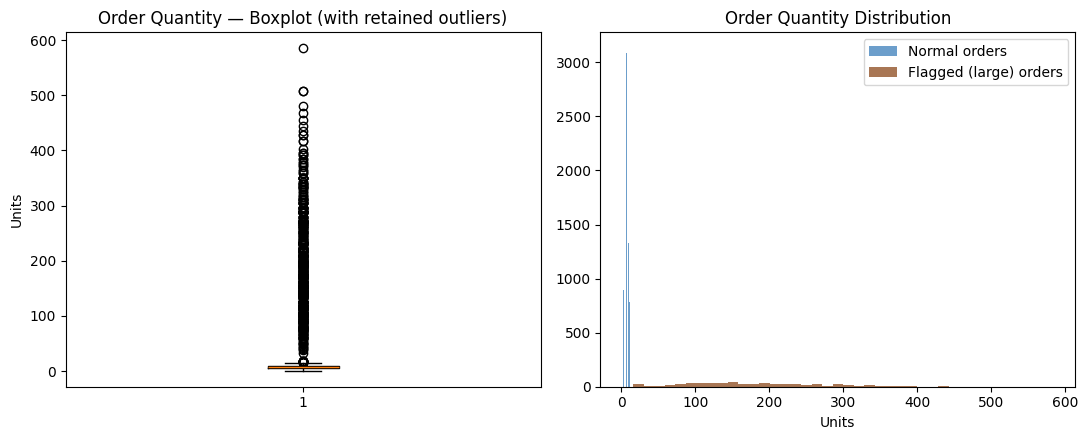

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].boxplot(df["qty"], vert=True)
axes[0].set_title("Order Quantity — Boxplot (with retained outliers)")
axes[0].set_ylabel("Units")

axes[1].hist(df.loc[~df["large_order_flag"], "qty"], bins=40, alpha=0.7, label="Normal orders", color="#2E75B6")
axes[1].hist(df.loc[df["large_order_flag"], "qty"], bins=40, alpha=0.7, label="Flagged (large) orders", color="#833C0C")
axes[1].set_title("Order Quantity Distribution")
axes[1].set_xlabel("Units")
axes[1].legend()
plt.tight_layout()
plt.show()


## 7. Feature Scaling for Downstream Clustering

Outlet-level aggregated features (average order quantity, order frequency, latitude, longitude) are
standardized (Z-score) before being handed to a distance-based clustering algorithm, since raw scale
differences between these fields (single digits vs. thousands) would otherwise dominate the distance
metric regardless of true importance.

In [14]:
outlet_features = df.groupby("outlet_id").agg(
    avg_order_qty=("qty", "mean"),
    order_frequency=("order_id", "count"),
    lat=("lat", "first"),
    lon=("lon", "first"),
).dropna()

print("Before scaling:")
print(outlet_features.describe().loc[["mean", "std"]].round(2))

scaler = StandardScaler()
scaled = scaler.fit_transform(outlet_features[["avg_order_qty", "order_frequency", "lat", "lon"]])
scaled_df = pd.DataFrame(scaled, columns=outlet_features.columns, index=outlet_features.index)

print("\nAfter standardization:")
print(scaled_df.describe().loc[["mean", "std"]].round(3))


Before scaling:
      avg_order_qty  order_frequency   lat    lon
mean          12.01            79.27  16.5  80.62
std            3.95             8.25   0.1   0.07

After standardization:
      avg_order_qty  order_frequency    lat    lon
mean          0.000           -0.000  0.000  0.000
std           1.002            1.002  1.002  1.002


## 8. Final Validation & Export

A short set of assertions confirms the pipeline has actually resolved every targeted issue before the
cleaned dataset is written to disk for use in later analysis stages.

In [15]:
assert df["sku_id"].str.contains(r"\s").sum() == 0, "Whitespace remains in sku_id"
assert df.duplicated(subset=["order_id"]).sum() == 0, "Duplicates remain"
assert (df["qty"] > 0).all(), "Non-positive quantities remain"
assert df["promised_date"].isna().sum() == 0, "Unresolved missing promised_date"

print("All validation checks passed.")

df.to_csv("orders_clean.csv", index=False)
print(f"Cleaned dataset written: orders_clean.csv — final shape {df.shape}")


All validation checks passed.
Cleaned dataset written: orders_clean.csv — final shape (19818, 15)


## 9. Before / After Summary

In [16]:
audit_after = {
    "Total rows": len(df),
    "Duplicate order_id rows": df.duplicated(subset=["order_id"]).sum(),
    "Missing delivery_date (flagged, retained)": (~df["delivered_flag"]).sum(),
    "Missing promised_date": df["promised_date"].isna().sum(),
    "Non-positive qty": (df["qty"] <= 0).sum(),
    "Zero/negative unit_price": (df["unit_price"] <= 0).sum(),
    "sku_id with whitespace/casing issues": df["sku_id"].ne(df["sku_id"].str.strip().str.upper()).sum(),
    "Outlets missing coordinates": df["lat"].isna().sum(),
}
audit_after_df = pd.DataFrame.from_dict(audit_after, orient="index", columns=["Count (after)"])

summary = audit_before_df[["Count"]].rename(columns={"Count": "Count (before)"}).join(audit_after_df)
summary


,Count (before),Count (after)
Total rows,20360,19818.0
Duplicate order_id rows,360,0.0
Missing delivery_date,1303,NaN
Missing promised_date,427,0.0
Non-positive qty,91,0.0
Zero/negative unit_price,92,0.0
sku_id with whitespace/casing issues,3059,0.0
Outlets missing coordinates,8,0.0


### Reflection

The comparison above shows every targeted data-quality issue resolved or (in the case of missing
delivery dates and flagged large orders) explicitly and transparently retained rather than silently
imputed away. This distinction matters: naive blanket cleaning would have inflated the On-Time Delivery
Rate by dropping or imputing incomplete delivery records, and would have discarded genuine bulk-order
demand signal that the Week 1 forecasting model needs. The cleaned `orders_clean.csv` produced here is
now ready to feed directly into the exploratory analysis, clustering, and forecasting steps built in the
Week 1 notebook — with the same schema, but with quality guarantees the raw extract did not have.
